# PCA Decomposition — explained variance & class separability

The decomposition stage is **off by default** (`stages.decomposition: false`): a
CNN needs the raw 48×48 spatial layout that PCA would flatten away. This notebook
is the *teaching ablation* — it shows:

1. the **cumulative explained-variance curve** (how many components capture most
   of the pixel variance), and
2. a **2-D PCA scatter** colored by emotion (how separable the classes are in the
   top-2 components).

Both use the real `PcaReducer`, fit on the **training split only**. See `data.md §6`
for the on/off rationale.

## 0. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.emotion_detector.utils.config import load_config
from src.emotion_detector.utils.logging import setup_logging
from src.emotion_detector.data.fer2013 import Fer2013Fetcher
from src.emotion_detector.data.decomposition import PcaReducer

cfg = load_config(ROOT / "config.yaml")
for key in cfg["paths"]:
    cfg["paths"][key] = str(ROOT / cfg["paths"][key])
setup_logging(cfg)

SEED = cfg["global"]["seed"]
EDA_DIR = Path(cfg["paths"]["results_dir"]) / "eda"
EDA_DIR.mkdir(parents=True, exist_ok=True)
EMOTION_LABELS = {
    0: "Angry", 1: "Disgust", 2: "Fear",
    3: "Happy", 4: "Sad",     5: "Surprise", 6: "Neutral",
}

2026-07-04 23:33:42 | INFO     | src.emotion_detector.utils.logging:61 — Logging initialised — level=INFO, log_dir=D:\emotions-detecto\logs


## 1. Load training images (fit PCA on train only)

In [2]:
X_train, y_train = Fer2013Fetcher(cfg).fetch("Training")
print(f"train: {X_train.shape} → {X_train.shape[0]} vectors of "
      f"{X_train.shape[1] * X_train.shape[2]} pixels")

2026-07-04 23:33:46 | INFO     | src.emotion_detector.data.fer2013:89 — Loading split 'Training': 28,709 rows from icml_face_data.csv
2026-07-04 23:33:49 | INFO     | src.emotion_detector.data.fer2013:104 — Split 'Training' ready — images (28709, 48, 48) uint8, labels (28709,)


train: (28709, 48, 48) → 28709 vectors of 2304 pixels


## 2. Cumulative explained variance

PCA orders components by how much pixel variance each captures. The cumulative
curve tells us how many components are enough — the elbow is where extra
components stop buying much information.

2026-07-04 23:36:11 | INFO     | src.emotion_detector.data.decomposition:63 — PcaReducer fit on train — kept 1798 components (from 2304), explaining 99.9% of variance.


90% variance → 103 components (4.5% of the 2304 pixels)
95% variance → 253 components (11.0% of the 2304 pixels)
99% variance → 880 components (38.2% of the 2304 pixels)
Saved: D:\emotions-detecto\results\eda\pca_explained_variance.png


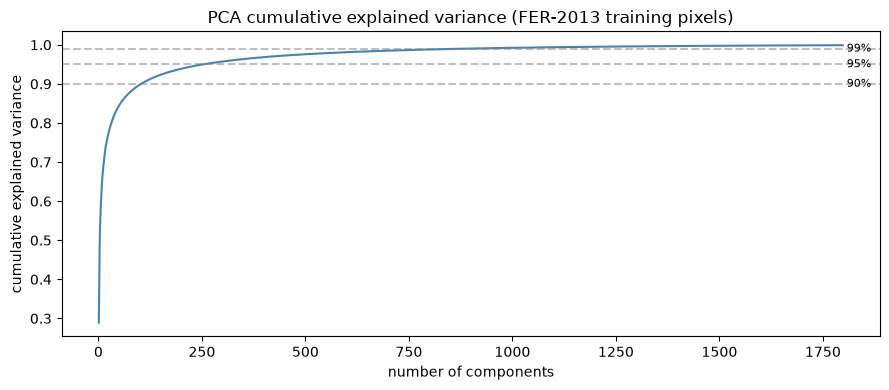

In [3]:
# Fit enough components to reach 99.9% variance, then read the curve.
reducer = PcaReducer(n_components=0.999, seed=SEED).fit(X_train)
cum = np.cumsum(reducer.explained_variance_ratio_)

for thr in (0.90, 0.95, 0.99):
    k = int(np.searchsorted(cum, thr) + 1)
    print(f"{int(thr * 100)}% variance → {k} components "
          f"({k / X_train[0].size:.1%} of the {X_train[0].size} pixels)")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cum) + 1), cum, color="steelblue")
for thr in (0.90, 0.95, 0.99):
    ax.axhline(thr, ls="--", color="gray", alpha=0.5)
    ax.text(len(cum), thr, f" {int(thr*100)}%", va="center", fontsize=8)
ax.set_xlabel("number of components")
ax.set_ylabel("cumulative explained variance")
ax.set_title("PCA cumulative explained variance (FER-2013 training pixels)")
plt.tight_layout()
fig.savefig(EDA_DIR / "pca_explained_variance.png", dpi=120, bbox_inches="tight")
print(f"Saved: {EDA_DIR / 'pca_explained_variance.png'}")
plt.show()

## 3. 2-D PCA scatter, colored by emotion

Projecting onto the top 2 components shows whether emotions form separable
clusters in that 2-D space. For raw FER-2013 pixels we expect **heavy overlap** —
the top-2 components capture coarse lighting/pose, not expression. That overlap is
the visual argument for a CNN (which learns expression-specific spatial features)
over a linear model on PCA features.

2026-07-04 23:36:13 | INFO     | src.emotion_detector.data.decomposition:63 — PcaReducer fit on train — kept 2 components (from 2304), explaining 38.7% of variance.


Saved: D:\emotions-detecto\results\eda\pca_scatter_2d.png


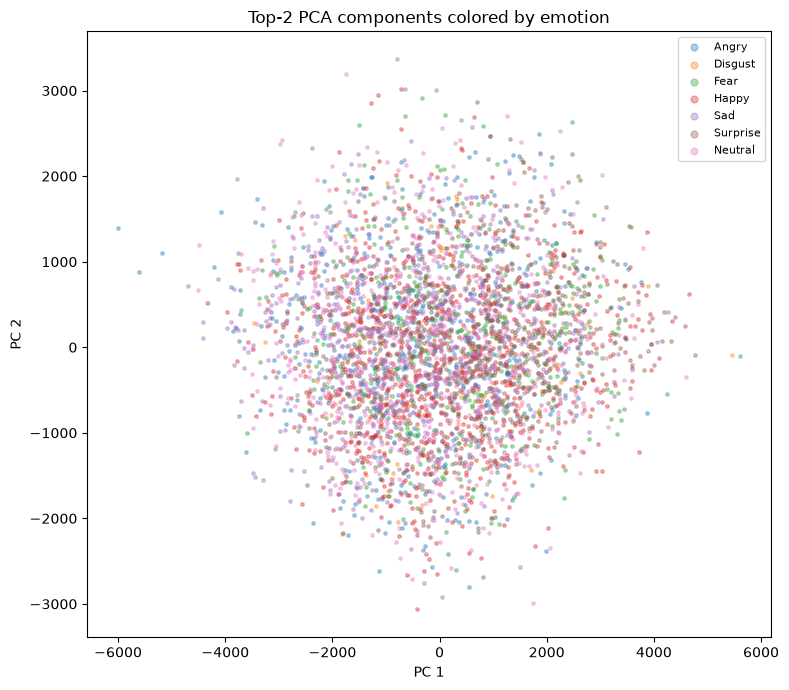

In [4]:
# subsample for a readable scatter (seeded)
rng = np.random.default_rng(SEED)
idx = rng.choice(len(X_train), size=min(4000, len(X_train)), replace=False)

reducer_2d = PcaReducer(n_components=2, seed=SEED).fit(X_train)
Z = reducer_2d.transform(X_train[idx])
y_sub = y_train[idx]

fig, ax = plt.subplots(figsize=(8, 7))
for code in sorted(EMOTION_LABELS):
    m = y_sub == code
    ax.scatter(Z[m, 0], Z[m, 1], s=6, alpha=0.35, label=EMOTION_LABELS[code])
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
ax.set_title("Top-2 PCA components colored by emotion")
ax.legend(markerscale=2, fontsize=8)
plt.tight_layout()
fig.savefig(EDA_DIR / "pca_scatter_2d.png", dpi=120, bbox_inches="tight")
print(f"Saved: {EDA_DIR / 'pca_scatter_2d.png'}")
plt.show()

## 4. Findings (from this run — 28,709 training images)

**Explained variance — the pixels are highly redundant:**

| Target | Components | Fraction of 2,304 pixels |
|---|---|---|
| 90 % | 103 | 4.5 % |
| 95 % | 253 | 11.0 % |
| 99 % | 880 | 38.2 % |

The first component alone captures ~29 %, and 90 % of all variance lives in just
**103 of 2,304** dimensions. Neighbouring pixels are strongly correlated, so PCA
compresses the images dramatically — exactly why it is useful for a **linear
baseline** (fewer, decorrelated features train faster).

**2-D separability — none:** the top-2 components explain **38.7 %** of variance,
yet the scatter (§3) is a single overlapping blob — all seven emotions are
completely intermingled. Those top components encode coarse **global brightness /
pose**, not expression. A linear model on these features cannot separate emotions.

**Conclusion:** this is precisely the case for keeping PCA **off** for the CNN.
Convolutions learn *local, expression-specific* spatial features (a raised brow, a
curved mouth) that live in the many small-variance directions PCA discards first —
so flattening to top components throws away the very signal the task needs. The
production CNN runs with `stages.decomposition: false`; see `data.md §6`."